<a href="https://colab.research.google.com/github/Areeb575/231A030_NLP-Experiments/blob/main/nlpexp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import nltk
from nltk.corpus import twitter_samples
import matplotlib.pyplot as plt
import random

In [ ]:
nltk.download("twitter_samples")

[nltk_data] Downloading package twitter_samples to /root/nltk_data...
[nltk_data]   Unzipping corpora/twitter_samples.zip.


True

In [ ]:
import nltk
from nltk.corpus import twitter_samples

In [ ]:
tweets=twitter_samples.strings()

In [ ]:
type(tweets)

list

In [ ]:
len(tweets)

30000

In [ ]:
import pandas as pd
all_tweets=pd.DataFrame(tweets, columns=["Tweets"])
all_tweets.tail()

,Tweets
29995,RT @UKLabour: .@Ed_Miliband: we're not going t...
29996,RT @DisabledScot: @blairmcdougall @ScotlandTon...
29997,RT @Staircase2: @VividRicky exactly but that a...
29998,Actually agreed with %95 of what farage was sa...
29999,"RT @PeatWorrier: ""A vote for the SNP is. Er. A..."


In [ ]:
"len of first",len(tweets[0])

('len of first', 19)

In [ ]:
twitter_samples.fileids()

['negative_tweets.json', 'positive_tweets.json', 'tweets.20150430-223406.json']

In [ ]:
pos_tweets=twitter_samples.strings("positive_tweets.json")
neg_tweets=twitter_samples.strings("negative_tweets.json")

In [ ]:
len(pos_tweets)


5000

In [ ]:
len(neg_tweets)

5000

In [ ]:
pos_tweets=pd.DataFrame(pos_tweets, columns=["Tweets"])
pos_tweets["Sentiments"]="Positive"
pos_tweets.tail()

,Tweets,Sentiments
4995,"@chriswiggin3 Chris, that's great to hear :) D...",Positive
4996,@RachelLiskeard Thanks for the shout-out :) It...,Positive
4997,@side556 Hey! :) Long time no talk...,Positive
4998,@staybubbly69 as Matt would say. WELCOME TO AD...,Positive
4999,@DanielOConnel18 you could say he will have eg...,Positive


In [ ]:
neg_tweets=pd.DataFrame(neg_tweets, columns=["Tweets"])
neg_tweets["Sentiments"]="Negative"
neg_tweets.tail()

,Tweets,Sentiments
4995,I wanna change my avi but uSanele :(,Negative
4996,MY PUPPY BROKE HER FOOT :(,Negative
4997,where's all the jaebum baby pictures :((,Negative
4998,But but Mr Ahmad Maslan cooks too :( https://t...,Negative
4999,@eawoman As a Hull supporter I am expecting a ...,Negative


In [ ]:
tweets=pd.concat([pos_tweets,neg_tweets],ignore_index=False)
tweets=tweets.sample(frac=1).reset_index(drop=True)
tweets

,Tweets,Sentiments
0,@Tweetnesian pake :),Positive
1,Ken Saras. Waiting for my sister. She was in a...,Negative
2,@ScottReevesFans where s his official account?...,Positive
3,@GabyInTheFields Consider yourself lucky! my f...,Negative
4,Welcome to the family :) https://t.co/TGiFQ0qjnM,Positive
...,...,...
9995,Hi BAM ! @BarsAndMelody \nCan you follow my be...,Positive
9996,Gratefulness = Happiness :) Post three things ...,Positive
9997,@envydanneh need to put me in that rotation lo...,Positive
9998,Just got home!:))),Positive


In [ ]:
import numpy as np
tweets[tweets["Sentiments"]=="Positive"].value_counts().sum()
tweets[tweets["Sentiments"]=="Negative"].value_counts().sum()

np.int64(5000)

In [ ]:
y_positive=(tweets["Sentiments"]=="Positive").sum()
y_negative=(tweets["Sentiments"]=="Negative").sum()
print(y_positive,y_negative)

5000 5000


In [ ]:
tweet1=all_tweets.iloc[1000]
tweet1["Tweets"]

"@seanactual You mean you're not offering? :("

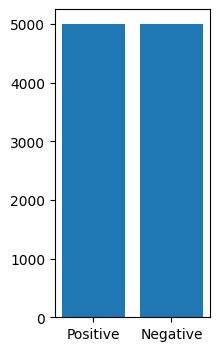

In [ ]:
fig=plt.figure(figsize=(2,4))
labels=["Positive","Negative"]
sizes=[y_positive,y_negative]
plt.bar(labels,sizes)
plt.show()

process 1

In [ ]:
tweet1=all_tweets.iloc[1000]
tweet1["Tweets"]

"@seanactual You mean you're not offering? :("

import lib

In [ ]:
import re
import string
from  nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import TweetTokenizer

In [ ]:
# remove old style retweet text "RT"
tweet2 = re.sub(r'^RT[\s]+', '', tweet1["Tweets"])

# remove hyperlinks
tweet2 = re.sub(r'https?://[^\s\n\r]+', '', tweet2)

# remove hashtags
# only removing the hash # sign from the word
tweet2 = re.sub(r'#', '', tweet2)
tweet2 = re.sub(r'@\w+', '', tweet2)
tweet2 = re.sub(r'[:)(;]', '', tweet2)

print(tweet1["Tweets"])
print("\n Cleaned tweet: \n", tweet2)

@seanactual You mean you're not offering? :(

 Cleaned tweet: 
  You mean you're not offering? 


tokenization

In [ ]:
tokenizer=TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
tweet_tokens=tokenizer.tokenize(tweet2)
print("tokenixd string")
print(tweet_tokens)

tokenixd string
['you', 'mean', "you're", 'not', 'offering', '?']


In [ ]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

remove stopwords and punctuation

In [ ]:
stopwordsE= stopwords.words('english')
print("stopwords\n")
print(stopwordsE)
print("\nPunctuation marks\n")
print(string.punctuation)

stopwords

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "sh

In [ ]:
print(len(stopwordsE))

198


In [ ]:
tweet = tweet1["Tweets"] # Initialize tweet
tweet = re.sub(r'^RT[\s]+', '', tweet)          # remove old style retweet text "RT"
tweet = re.sub(r'https?://.*[\r\n]*', '', tweet)  # remove hyperlinks

tweet = re.sub(r'#', '', tweet)                 # removing the hash # sign from the word
tweet = re.sub(r'@.*', '', tweet)
tweet = re.sub(r'[-()\"#/@;:<>{}`+=~|.!?,]', '', tweet)
 # tokenize tweets
tweet_tokens = tokenizer.tokenize(tweet)
stopwords_english = stopwords.words('english')

In [ ]:
print("Vijay Shanker", "UIN:xxxx\n")
print(tweet_tokens)
print()

tweets_clean = []

for word in tweet_tokens:  # Go through every word in your tokens list
    if (word not in stopwordsE and  # remove stopwords
        word not in string.punctuation):   # remove punctuation
        tweets_clean.append(word)

print('removed stop words and punctuation:')
print(tweets_clean)


Vijay Shanker UIN:xxxx

[]

removed stop words and punctuation:
[]


In [ ]:
def processTweet(tweet):
  tokenizer=TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)

  tweet = re.sub(r'^RT[\s]+', '', tweet)          # remove old style retweet text "RT"
  tweet = re.sub(r'https?:\/\/.*[\r\n]*', '', tweet)  # remove hyperlinks

  tweet = re.sub(r'#', '', tweet)                 # removing the hash # sign from the word
  tweet = re.sub(r'@.*', '', tweet)
  tweet = re.sub(r'[-()\"#/@;:<>{}`+=~|.!?,]', '', tweet)
   # tokenize tweets
  tweet_tokens = tokenizer.tokenize(tweet)
  stopwords_english = stopwords.words('english')
  tweets_clean = []

  for word in tweet_tokens:  # Go through every word in your tokens list
      if (word not in stopwords_english and
              word not in string.punctuation):  # remove stopwords and punctuation
          tweets_clean.append(word)

  return tweets_clean

In [ ]:
tweet1=all_tweets.iloc[100]
tweet=tweet1["Tweets"]
print(processTweet(tweet))

[]


In [ ]:
processed_tweets=all_tweets['Tweets'].apply(processTweet)
all_tweets['tweets_processed']=processed_tweets
pd.set_option('display.max_colwidth',None)
all_tweets

,Tweets,tweets_processed
0,hopeless for tmr :(,"[hopeless, tmr]"
1,Everything in the kids section of IKEA is so cute. Shame I'm nearly 19 in 2 months :(,"[everything, kids, section, ikea, cute, shame, nearly, 19, 2, months]"
2,@Hegelbon That heart sliding into the waste basket. :(,[]
3,"“@ketchBurning: I hate Japanese call him ""bani"" :( :(”\n\nMe too",[“]
4,"Dang starting next week I have ""work"" :(","[dang, starting, next, week, work]"
...,...,...
29995,"RT @UKLabour: .@Ed_Miliband: we're not going to do a deal with the SNP, there will be no coalition with the SNP. #bbcqt\nhttps://t.co/n65hTe…",[]
29996,"RT @DisabledScot: @blairmcdougall @ScotlandTonight @bbcqt If Ed thinks Scots will suddenly rush to vote Labour, we'll vote SNP, Labour just…",[]
29997,RT @Staircase2: @VividRicky exactly but that alleged commute was made up by Farage as was his 'discomfort' in allegedly 'not hearing Englis…,[]
29998,Actually agreed with %95 of what farage was sayin rhen#voteukip,"[actually, agreed, 95, farage, sayin, rhenvoteukip]"


In [ ]:
tweets['Tweets_processed'] = tweets['Tweets'].apply(process_tweet)
display(tweets[['Tweets_processed','sentiments']])

NameError: name 'process_tweet' is not defined

ends


In [ ]:
# tweet = all_tweets.iloc[150]
# tweet = tweet1["Tweets"]

# print(tweet)
# print()
# print(processTweet(tweet))

In [ ]:
# print("areeb ansari", "UIN:231A030")
# processedTweets = all_tweets["Tweets"].apply(processTweet)   # applying processTweet() to all positive tweets
# all_tweets["Tweets_processed"] = processedTweets              # creating a new column of processed tweets 'Tweets_processed'
# pd.set_option('display.max_colwidth', None)
# all_tweets

In [ ]:
# print("areeb ansari", "UIN:231A030")

# processed_tweets = all_tweets["Tweets"].apply(processTweet)  # applying processTweet() to all positive tweets

# all_tweets["Tweets_processed"] = processed_tweets  # creating a new column of processed tweets 'Tweets_processed'

# pd.set_option('display.max_colwidth', None)

# all_tweets